In [ ]:
!pip install pymongo prophet statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_ml.p_count.csv to data_ml.p_count (1).csv
Saving data_ml.p_count_2.csv to data_ml.p_count_2 (1).csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Lue tiedostot
df_aiot = pd.read_csv('data_ml.p_count (1).csv')
df_robo = pd.read_csv('data_ml.p_count_2 (1).csv')

# Muotoile päivämäärät
df_aiot['DateTime'] = pd.to_datetime(df_aiot['DateTime'], format='%d %b %Y %H:%M:%S', errors='coerce')
df_robo['DateTime'] = pd.to_datetime(df_robo['DateTime'], format='%d %b %Y %H:%M:%S', errors='coerce')

# Aseta indeksi
df_aiot = df_aiot.dropna(subset=['DateTime']).set_index('DateTime')
df_robo = df_robo.dropna(subset=['DateTime']).set_index('DateTime')

# Nimeä sarake selkeämmäksi
df_aiot = df_aiot.rename(columns={'person count': 'count'})
df_robo = df_robo.rename(columns={'person count': 'count'})

print(f"AIoT: {len(df_aiot)} riviä, {df_aiot.index.min()} → {df_aiot.index.max()}")
print(f"Robo: {len(df_robo)} riviä, {df_robo.index.min()} → {df_robo.index.max()}")

AIoT: 9100 riviä, 2026-01-13 09:36:07 → 2026-03-01 00:55:41
Robo: 9687 riviä, 2026-01-27 08:04:02 → 2026-03-03 11:47:30


In [ ]:
def siivoa_data(df):
    df = df.copy()

    # Poista epärealistiset arvot (max 60)
    df = df[df['count'] <= 60]

    # Aseta yöaika nollaksi (klo 20-07)
    yö = (df.index.hour >= 20) | (df.index.hour < 7)
    df.loc[yö, 'count'] = 0

    # Aseta viikonloppu nollaksi
    df.loc[df.index.dayofweek.isin([5, 6]), 'count'] = 0

    # Poista helmikuun alun tapahtuma
    df = df[~((df.index >= '2026-01-30') & (df.index <= '2026-02-05'))]

    # Tasoita liukuvalla keskiarvolla
    df['count_smooth'] = df['count'].rolling(5, min_periods=1).mean()

    return df

df_aiot = siivoa_data(df_aiot)
df_robo = siivoa_data(df_robo)

print(f"AIoT siivottu: {len(df_aiot)} riviä")
print(f"Robo siivottu: {len(df_robo)} riviä")

AIoT siivottu: 7556 riviä
Robo siivottu: 8199 riviä


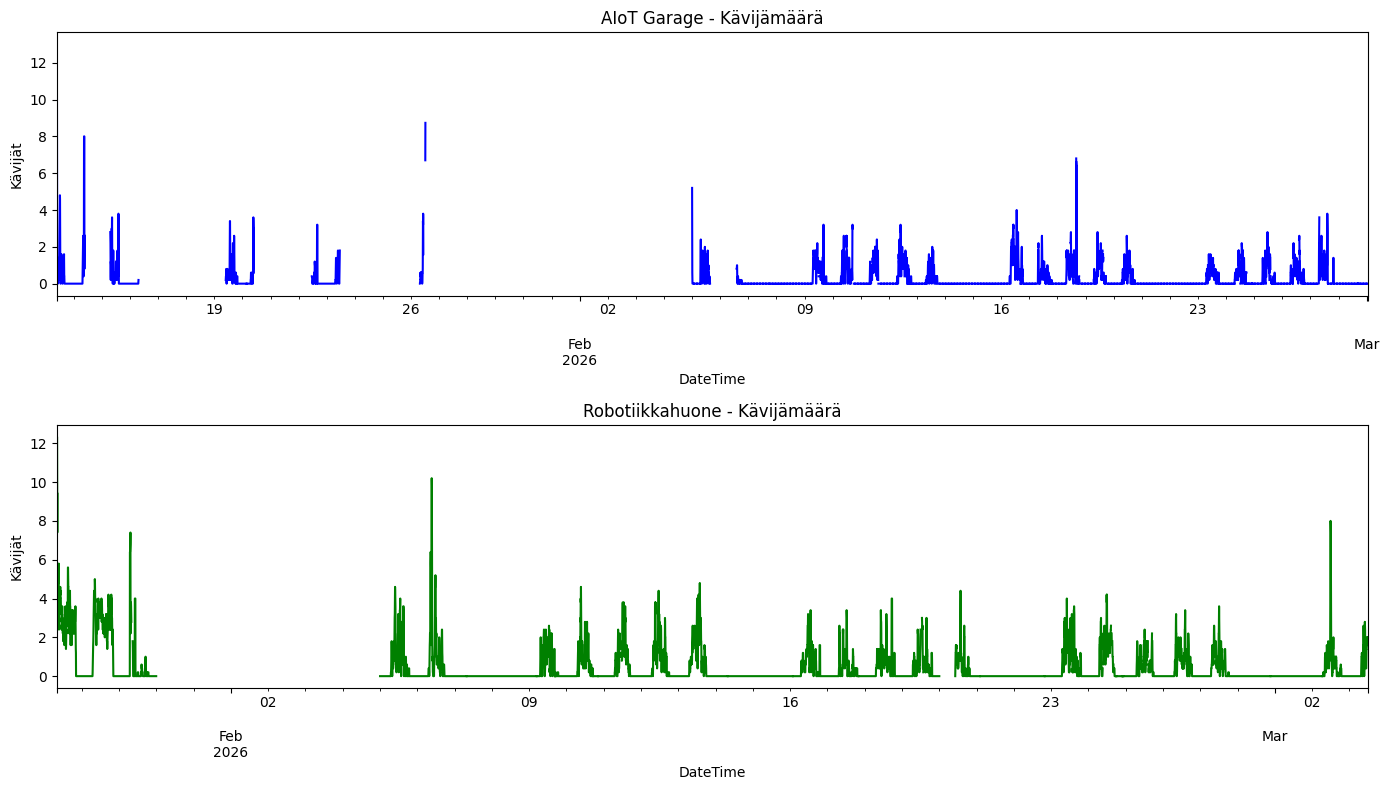

In [ ]:
# Visualisointi
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_aiot['count_smooth'].resample('5min').mean().plot(ax=axes[0],
    title='AIoT Garage - Kävijämäärä', color='blue')
axes[0].set_ylabel('Kävijät')

df_robo['count_smooth'].resample('5min').mean().plot(ax=axes[1],
    title='Robotiikkahuone - Kävijämäärä', color='green')
axes[1].set_ylabel('Kävijät')

plt.tight_layout()
plt.show()

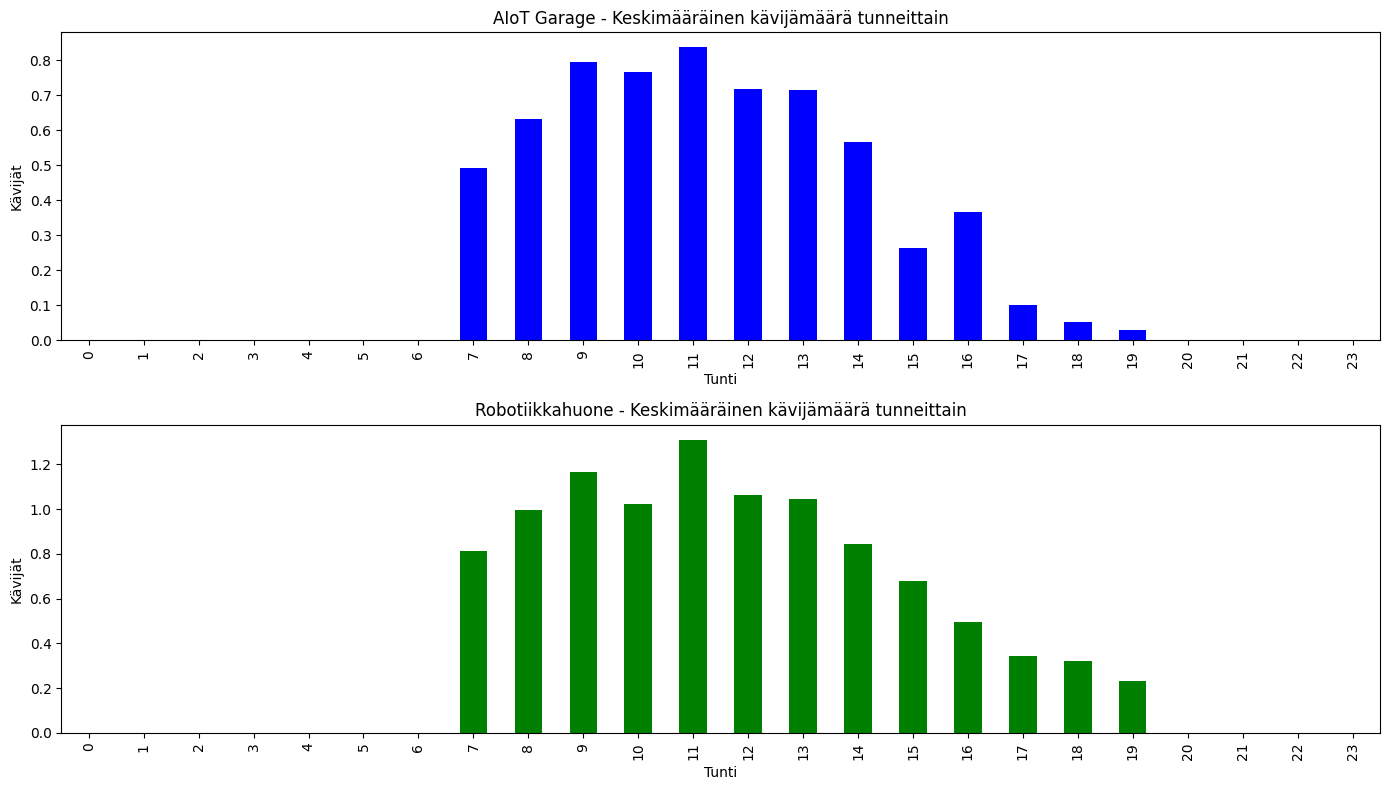

In [ ]:
# Tuntikeskiarvot molemmille tiloille
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_aiot.groupby(df_aiot.index.hour)['count'].mean().plot(kind='bar', ax=axes[0],
    title='AIoT Garage - Keskimääräinen kävijämäärä tunneittain', color='blue')
axes[0].set_xlabel('Tunti')
axes[0].set_ylabel('Kävijät')

df_robo.groupby(df_robo.index.hour)['count'].mean().plot(kind='bar', ax=axes[1],
    title='Robotiikkahuone - Keskimääräinen kävijämäärä tunneittain', color='green')
axes[1].set_xlabel('Tunti')
axes[1].set_ylabel('Kävijät')

plt.tight_layout()
plt.show()

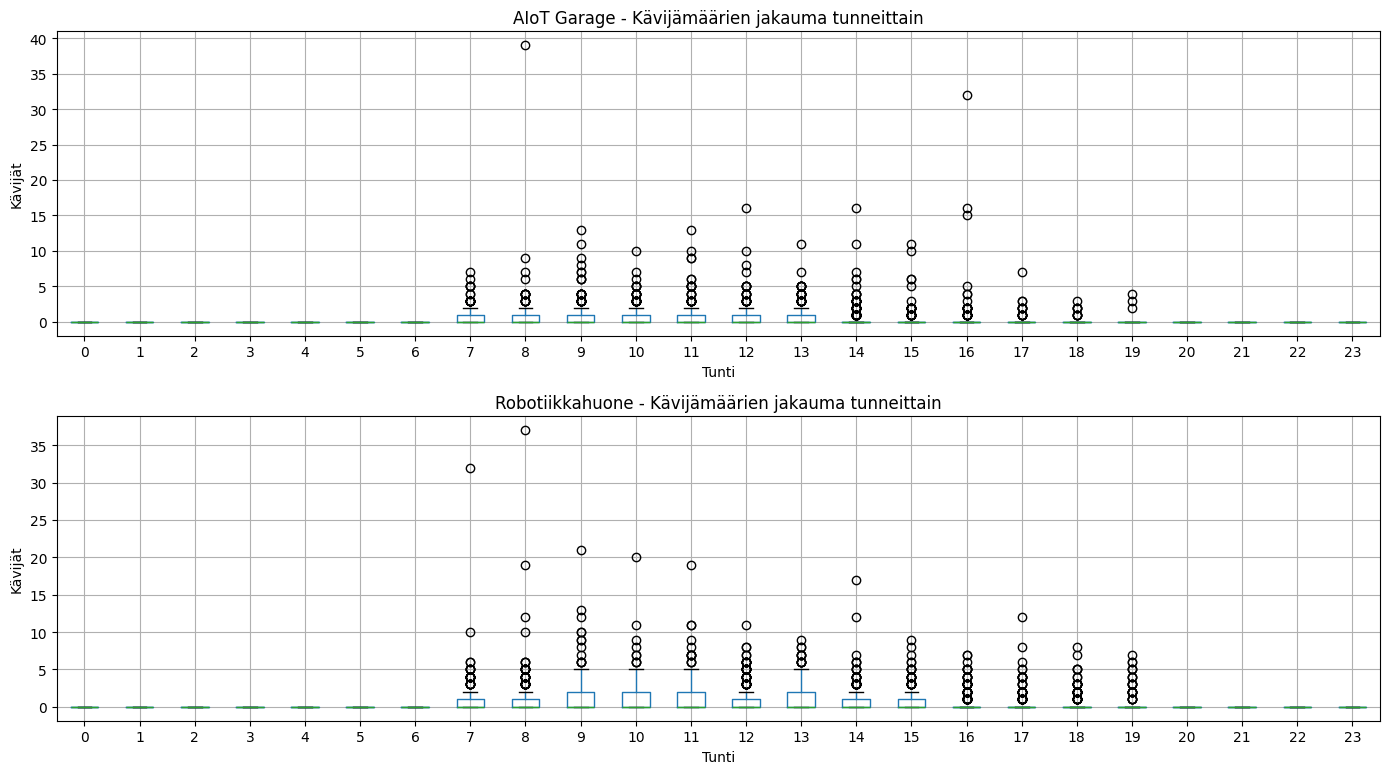

In [ ]:
df_aiot['hour'] = df_aiot.index.hour
df_robo['hour'] = df_robo.index.hour

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df_aiot.boxplot(column='count', by='hour', ax=axes[0])
axes[0].set_title('AIoT Garage - Kävijämäärien jakauma tunneittain')
axes[0].set_xlabel('Tunti')
axes[0].set_ylabel('Kävijät')

df_robo.boxplot(column='count', by='hour', ax=axes[1])
axes[1].set_title('Robotiikkahuone - Kävijämäärien jakauma tunneittain')
axes[1].set_xlabel('Tunti')
axes[1].set_ylabel('Kävijät')

plt.suptitle('')
plt.tight_layout()
plt.show()

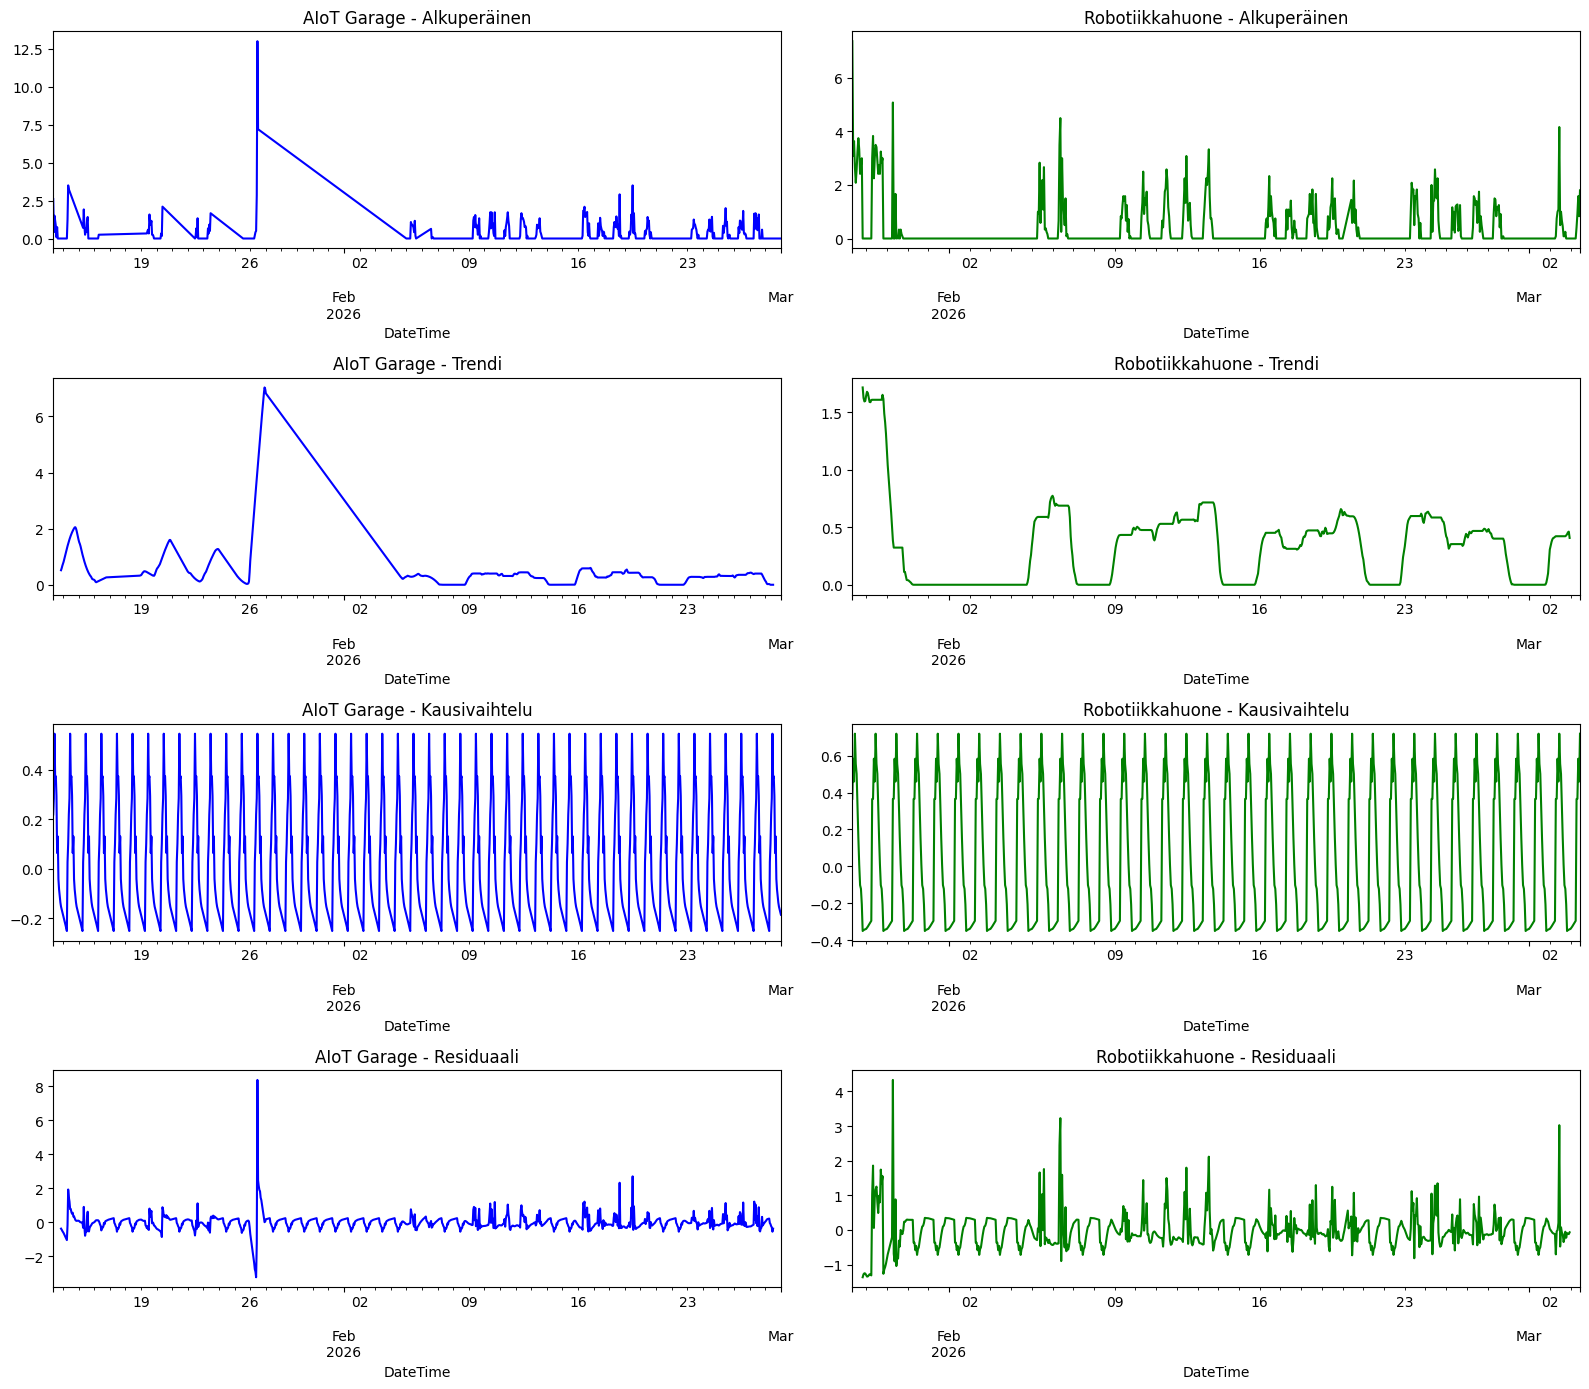

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (df, nimi, väri) in enumerate([(df_aiot, 'AIoT Garage', 'blue'),
                                       (df_robo, 'Robotiikkahuone', 'green')]):
    hourly = df['count'].resample('h').mean().interpolate()
    decomp = seasonal_decompose(hourly, model='additive', period=24)

    decomp.observed.plot(ax=axes[0][i], title=f'{nimi} - Alkuperäinen', color=väri)
    decomp.trend.plot(ax=axes[1][i], title=f'{nimi} - Trendi', color=väri)
    decomp.seasonal.plot(ax=axes[2][i], title=f'{nimi} - Kausivaihtelu', color=väri)
    decomp.resid.plot(ax=axes[3][i], title=f'{nimi} - Residuaali', color=väri)

plt.tight_layout()
plt.show()

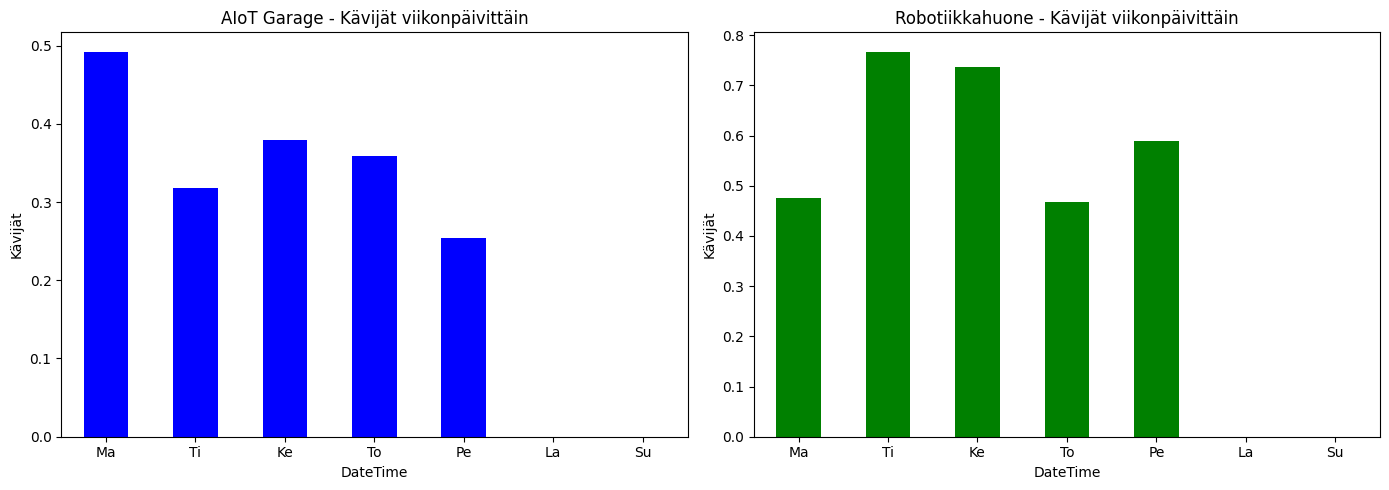

In [ ]:
# Vertailu viikonpäivittäin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

päivät = ['Ma', 'Ti', 'Ke', 'To', 'Pe', 'La', 'Su']

df_aiot.groupby(df_aiot.index.dayofweek)['count'].mean().plot(
    kind='bar', ax=axes[0], title='AIoT Garage - Kävijät viikonpäivittäin',
    color='blue', xticks=range(7))
axes[0].set_xticklabels(päivät, rotation=0)
axes[0].set_ylabel('Kävijät')

df_robo.groupby(df_robo.index.dayofweek)['count'].mean().plot(
    kind='bar', ax=axes[1], title='Robotiikkahuone - Kävijät viikonpäivittäin',
    color='green', xticks=range(7))
axes[1].set_xticklabels(päivät, rotation=0)
axes[1].set_ylabel('Kävijät')

plt.tight_layout()
plt.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



=== AIoT Garage ===
MAE: 0.50 kävijää
RMSE: 0.78 kävijää


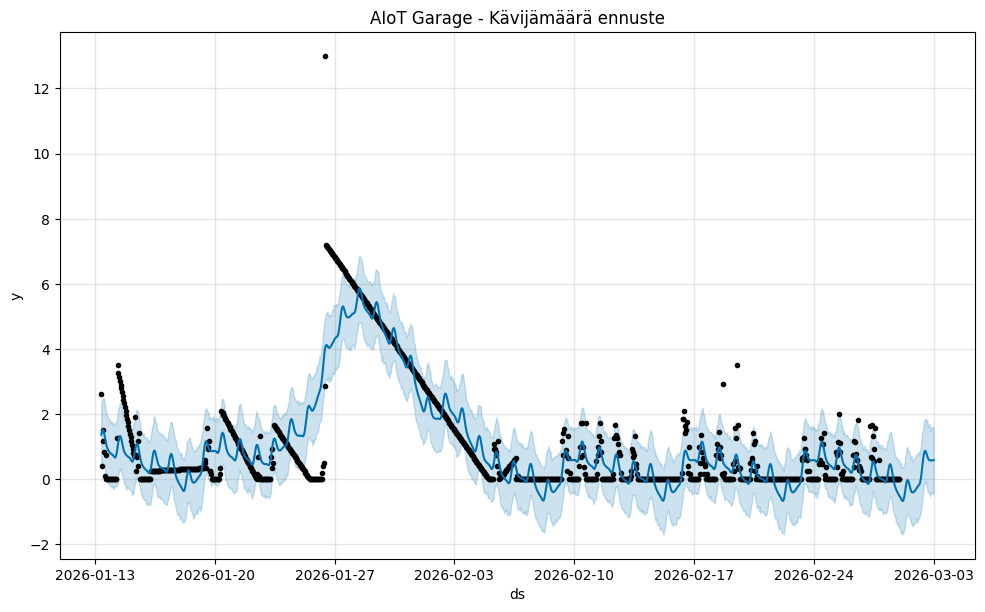

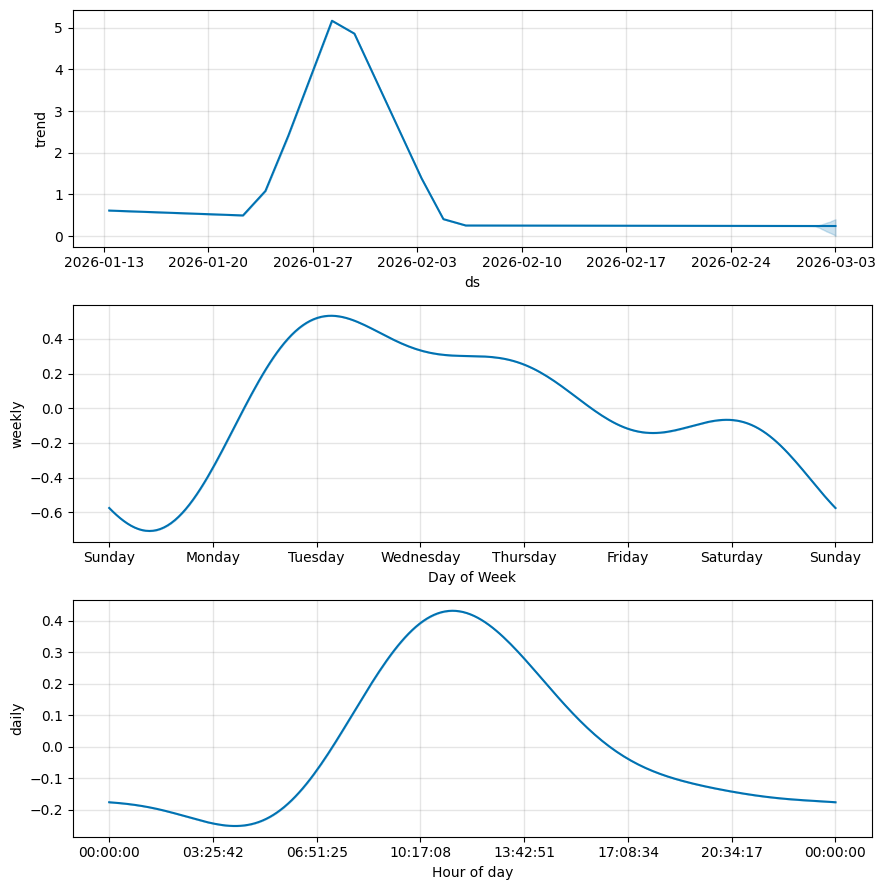

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



=== Robotiikkahuone ===
MAE: 0.39 kävijää
RMSE: 0.61 kävijää


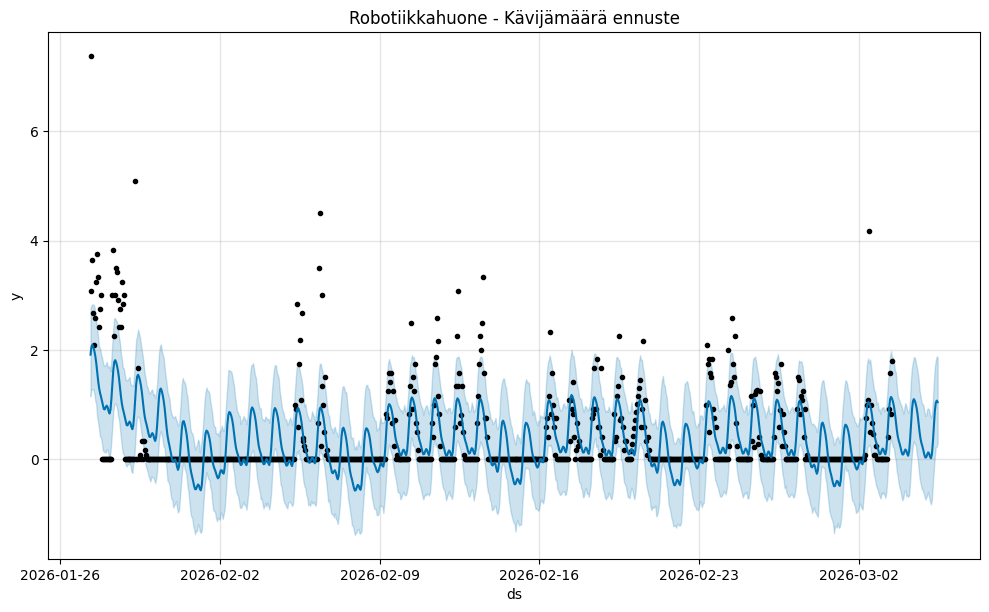

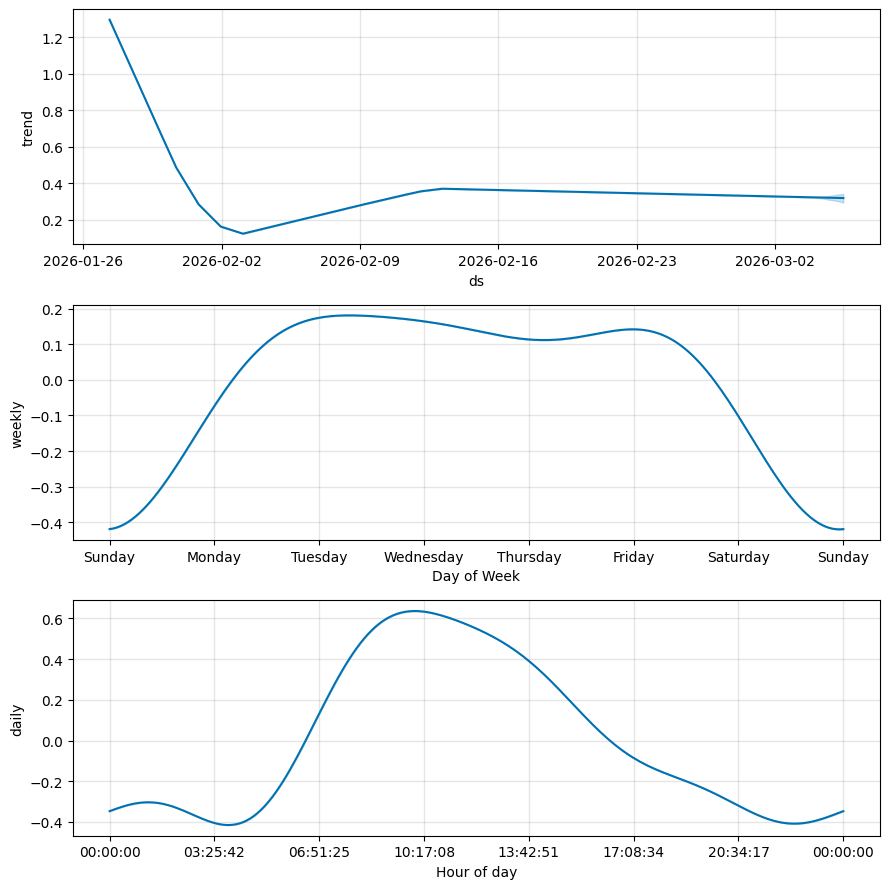

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def prophet_ennuste(df, nimi):
    # Valmistele data
    df_p = df[['count']].resample('h').mean().interpolate().reset_index()
    df_p.columns = ['ds', 'y']

    # Kouluta malli
    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    model.fit(df_p)

    # Ennusta seuraavat 48 tuntia
    future = model.make_future_dataframe(periods=48, freq='h')
    forecast = model.predict(future)

    # Laske tarkkuus
    merged = forecast.set_index('ds')[['yhat']].join(df_p.set_index('ds')['y'])
    merged = merged.dropna()
    mae = mean_absolute_error(merged['y'], merged['yhat'])
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

    print(f"\n=== {nimi} ===")
    print(f"MAE: {mae:.2f} kävijää")
    print(f"RMSE: {rmse:.2f} kävijää")

    # Visualisoi
    model.plot(forecast)
    plt.title(f'{nimi} - Kävijämäärä ennuste')
    plt.show()

    model.plot_components(forecast)
    plt.show()

prophet_ennuste(df_aiot, 'AIoT Garage')
prophet_ennuste(df_robo, 'Robotiikkahuone')


=== AIoT Garage - ARIMA ===
MAE: 0.28 kävijää
RMSE: 0.48 kävijää


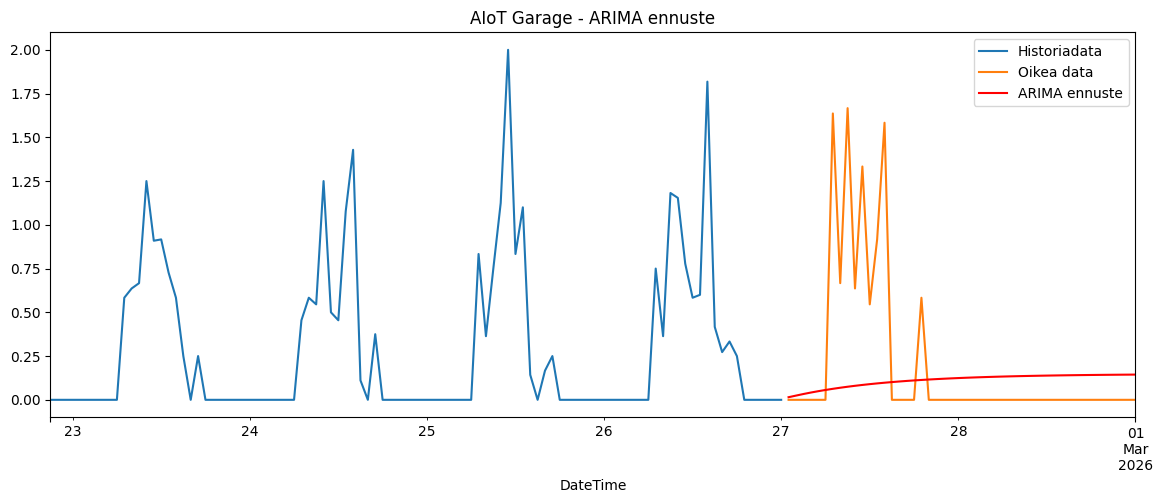


=== Robotiikkahuone - ARIMA ===
MAE: 0.33 kävijää
RMSE: 0.78 kävijää


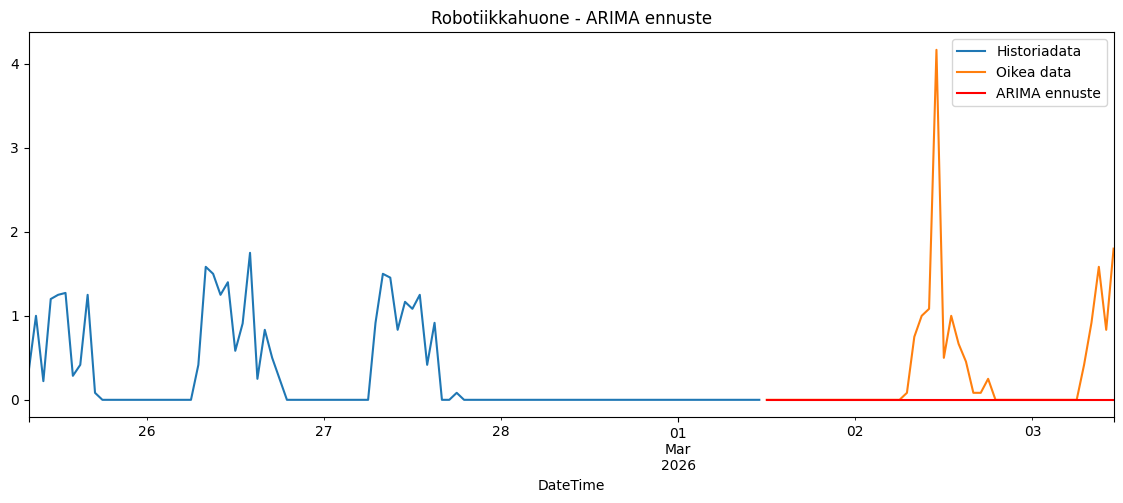

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

def arima_ennuste(df, nimi):
    # Valmistele data
    hourly = df['count'].resample('h').mean().interpolate()

    # Jaa train/test
    train = hourly[:-48]
    test = hourly[-48:]

    # Kouluta ARIMA malli
    model = ARIMA(train, order=(2, 1, 2))
    model_fit = model.fit()

    # Ennusta
    forecast = model_fit.forecast(steps=48)

    # Laske tarkkuus
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    print(f"\n=== {nimi} - ARIMA ===")
    print(f"MAE: {mae:.2f} kävijää")
    print(f"RMSE: {rmse:.2f} kävijää")

    # Visualisoi
    plt.figure(figsize=(14, 5))
    train[-100:].plot(label='Historiadata')
    test.plot(label='Oikea data')
    forecast.plot(label='ARIMA ennuste', color='red')
    plt.title(f'{nimi} - ARIMA ennuste')
    plt.legend()
    plt.show()

arima_ennuste(df_aiot, 'AIoT Garage')
arima_ennuste(df_robo, 'Robotiikkahuone')

In [ ]:
print("=== Mallien vertailu ===")
print(f"{'Malli':<20} {'Tila':<20} {'MAE':<10} {'RMSE':<10}")
print("-" * 60)
print(f"{'Prophet':<20} {'AIoT Garage':<20} {'0.50':<10} {'0.78':<10}")
print(f"{'Prophet':<20} {'Robotiikkahuone':<20} {'0.39':<10} {'0.61':<10}")
print(f"{'ARIMA':<20} {'AIoT Garage':<20} {'0.28':<10} {'0.48':<10}")
print(f"{'ARIMA':<20} {'Robotiikkahuone':<20} {'0.33':<10} {'0.78':<10}")
print("\nJohtopäätös:")
print("- ARIMA on tarkempi molemmissa tiloissa MAE:lla mitattuna")
print("- ARIMA AIoT Garage: paras tulos MAE 0.28 kävijää")
print("- Prophet on parempi isojen virheiden hallinnassa (RMSE) Robotiikkahuoneessa")
print("- Molemmat mallit erittäin tarkkoja — alle 1 kävijän virhe!")

=== Mallien vertailu ===
Malli                Tila                 MAE        RMSE      
------------------------------------------------------------
Prophet              AIoT Garage          0.50       0.78      
Prophet              Robotiikkahuone      0.39       0.61      
ARIMA                AIoT Garage          0.28       0.48      
ARIMA                Robotiikkahuone      0.33       0.78      

Johtopäätös:
- ARIMA on tarkempi molemmissa tiloissa MAE:lla mitattuna
- ARIMA AIoT Garage: paras tulos MAE 0.28 kävijää
- Prophet on parempi isojen virheiden hallinnassa (RMSE) Robotiikkahuoneessa
- Molemmat mallit erittäin tarkkoja — alle 1 kävijän virhe!
